In [74]:
import commNumWL
import importlib
importlib.reload(commNumWL)
from commNumWL import Modem, Mesure, Source, Canal
import matplotlib.pyplot as plt
import numpy as np

# Emetteur QPSK #

Le bloc supplémentaire (en émission et réception) pour une modulation sur fréquence porteur par rapport aux modulations en bande de base est le bloc de **translation de fréquence**.<br>
Son rôle est de translater le spectre du signal émis dans la bande de fréquences désirée.

Pour une moduation PAM ou ASK, les symboles de modulation sont des symboles **réels**.<br>
Pour une modulation PSK ou QAM, les symboles de modulation sont des symboles **complexes**

### Signal QPSK ###

QPSK : 1 symbole transporte 4 bits<br>
Nombre de symboles voulus : 50<br>

Puisque chaque symbole transporte 4 bits, le nombre total de bits ($ N_{bits} $) requis pour générer 50 symboles est donné par :<br>
$N_{bits} = Nombres \ de  \ symboles \times \ bits \ par \ symboles$<br>
$N_{bits} = 50 \times 2 $<br>
$N_{bits} = 100 $<br>


In [75]:
#Génération d"une séquence binaire pseudo aléatoire sur 20 bits
Bits = Source.random(100)

In [76]:
#Création d"un objet nommé modemQPSK par instantiation de la classe Modem
modemQPSK = Modem("PSK", 4, Bits)

#Visualisation d"attributs de l"objet modemPAM4 (créés dans le constructeur)
print(f"La valeur des symboles numériques est:\n{modemQPSK.symbs_num}\n")

#Application d"un maping sur la séquence binaire grâce à une methode
Symbs_QPSK = modemQPSK.mapping(np.sqrt(2))
print(f"La valeur des symboles de modulés est:\n {Symbs_QPSK}")

La valeur des symboles numériques est:
[[1 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [0 1]
 [1 1]
 [0 1]
 [1 1]
 [0 1]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [0 0]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 0]
 [0 0]
 [1 0]
 [0 1]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]]

La valeur des symboles de modulés est:
 [-1.-1.j  1.+1.j  1.-1.j  1.+1.j -1.-1.j  1.-1.j  1.-1.j  1.+1.j -1.+1.j
  1.-1.j -1.+1.j  1.-1.j -1.+1.j  1.-1.j  1.-1.j -1.-1.j  1.+1.j -1.+1.j
  1.+1.j  1.-1.j  1.-1.j -1.+1.j -1.-1.j -1.+1.j -1.+1.j  1.+1.j -1.-1.j
 -1.+1.j -1.+1.j -1.+1.j -1.-1.j -1.-1.j  1.+1.j  1.+1.j  1.-1.j  1.+1.j
  1.+1.j -1.-1.j  1.+1.j -1.-1.j  1.+1.j -1.-1.j -1.+1.j -1.+1.j  1.+1.j
  1.-1.j  1.+1.j  1.-1.j  1.+1.j  1.+1.j]


### Affichage des bits et des symboles modulés ###

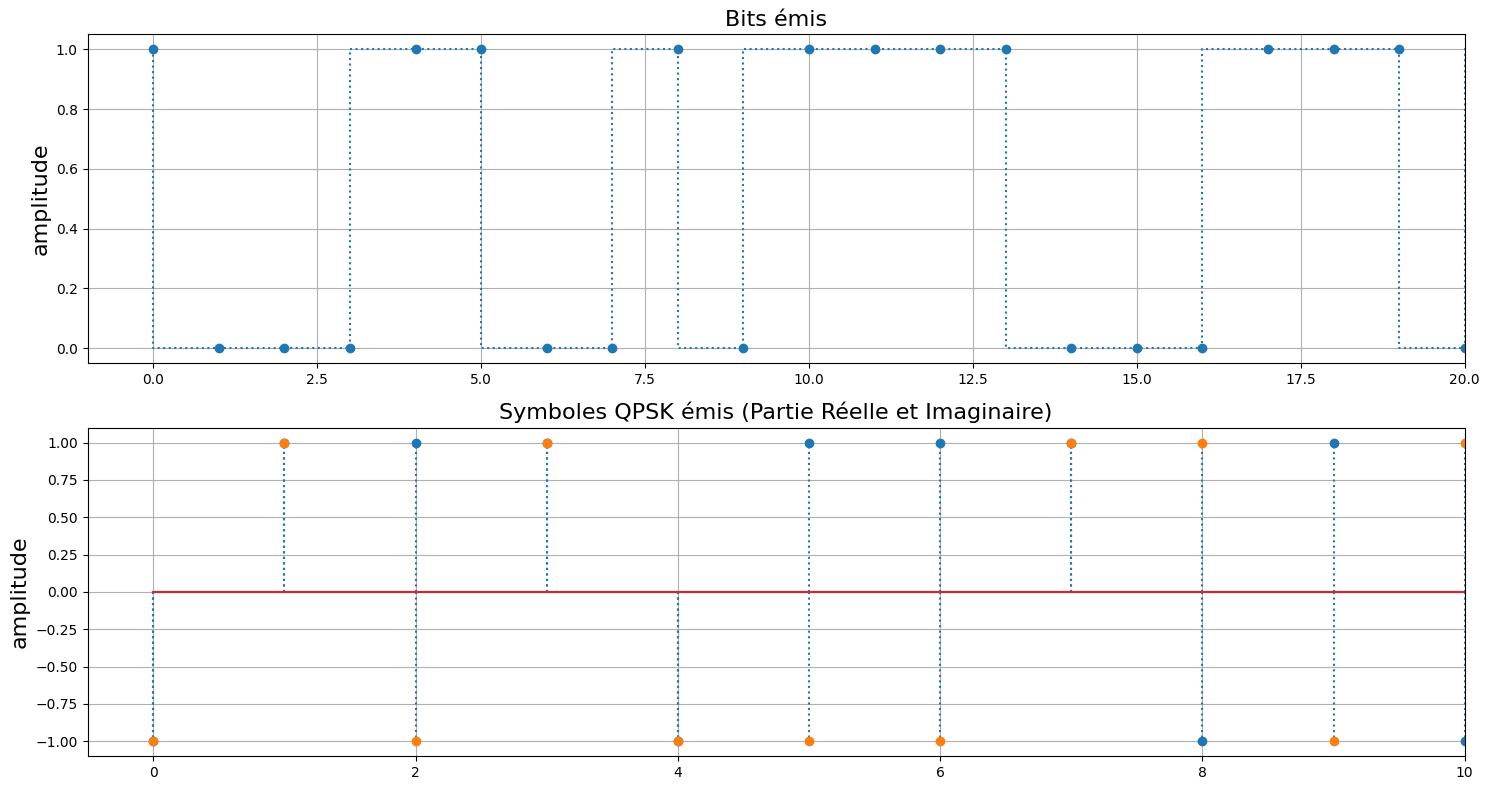

In [77]:
#Vecteur d"échantillons
t1 = np.arange(0, len(Bits))
t2 = np.arange(0, len(Symbs_QPSK))

#Affichage des symboles de modulés puis du signal QPSK après filtre de mis en forme
fig, ax = plt.subplots(2, 1, figsize = (15,8))

ax[0].step(t1 , Bits, ":o")
ax[0].set_title("Bits émis", fontsize = 16)
ax[0].set_ylabel("amplitude", fontsize = 16)
ax[0].set_xlim(-1, 20)
ax[0].grid()

ax[1].stem(t2, np.real(Symbs_QPSK), ":o")
ax[1].stem(t2, np.imag(Symbs_QPSK), ":o")
ax[1].set_xlim(-0.5, 10)
ax[1].grid()
ax[1].set_title("Symboles QPSK émis (Partie Réelle et Imaginaire)", fontsize = 16)
ax[1].set_ylabel("amplitude", fontsize = 16)

plt.tight_layout()

### Diagramme de constellation QPSK ###

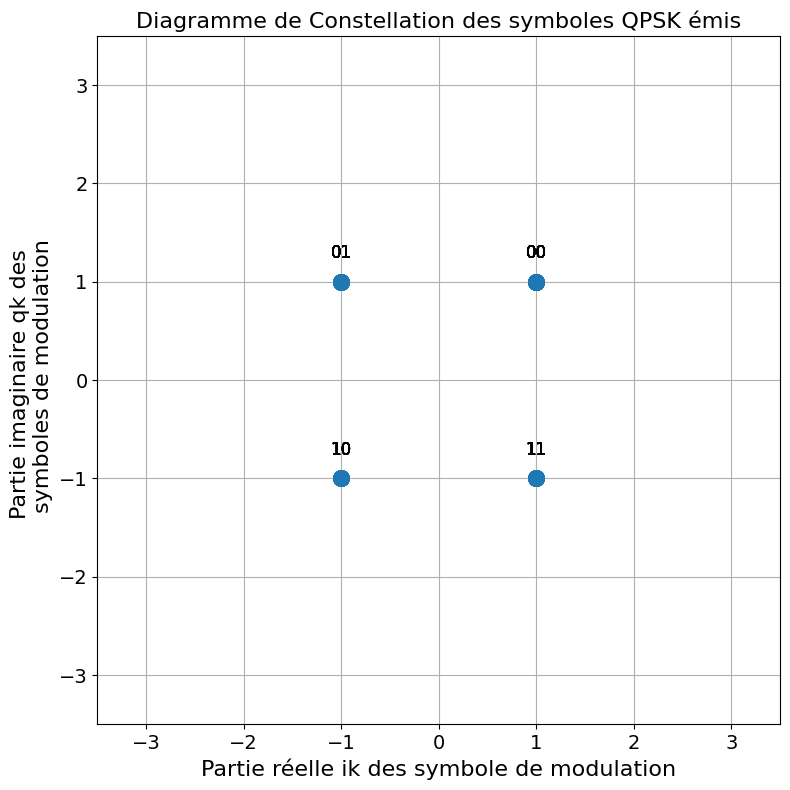

In [78]:
Mesure.constellation(Symbs_QPSK, modemQPSK.symbs_num, width=8, title="Diagramme de Constellation des symboles QPSK émis")

**Données:**
- $ R = 50 $
- $ \frac{1}{T_S} = 50 $
- $ T_S = \frac{1}{50} $
- $ T_S = 0.02 $

**Pour QPSK:**
- 2 bits par symbole
- $ T_b = \frac{T_S}{2} $
- $ T_b = 0.01 $
- $ D = \frac{1}{T_b} $
- $ D = 100 $

**Echantillonage:**
- $ f_e = 10^3 $
- $ f_e = R \times \text{upsampling} $
- $ \text{upsampling} = \frac{f_e}{R} $
- $ \text{upsampling} = \frac{10^3}{50} $
- $ \text{upsampling} = 200 $

**Fréquence porteuse:**
- $ f_p = 500 $


In [79]:
#Paramètres de la modulation
R = 50
fe = 10e3
te = 1/fe
fp = 500
upsampling = int(fe/R)

### Filtre de mise en forme rectangulaire ###

Le signal numériques QPSK après filtre de mise en forme est :
[-1.-1.j -1.-1.j -1.-1.j ...  1.+1.j  1.+1.j  1.+1.j]



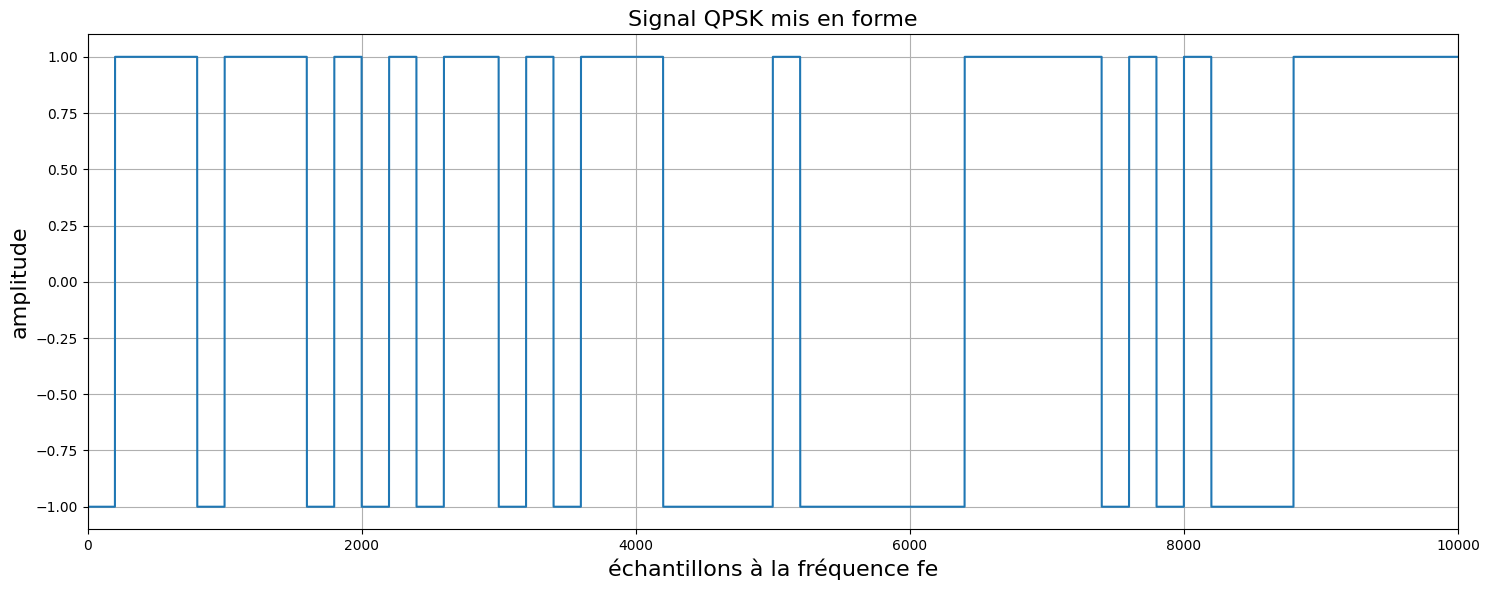

In [101]:
#Filtre de mise en forme
Signal_QPSK = modemQPSK.filtre_MF(Symbs_QPSK, upsampling)
print(f"Le signal numériques QPSK après filtre de mise en forme est :\n{Signal_QPSK}\n")

ech = np.arange(0, len(Signal_QPSK))

fig, ax = plt.subplots(figsize = (15,6))

ax.plot(ech, np.real(Signal_QPSK))
ax.set_title("Signal QPSK mis en forme", fontsize = 16)
ax.set_xlabel("échantillons à la fréquence fe", fontsize = 16)
ax.set_ylabel("amplitude", fontsize = 16)
ax.set_xlim(0,10000)
ax.grid()
plt.tight_layout()

### Upconversion et affichage du signal QPSK ###

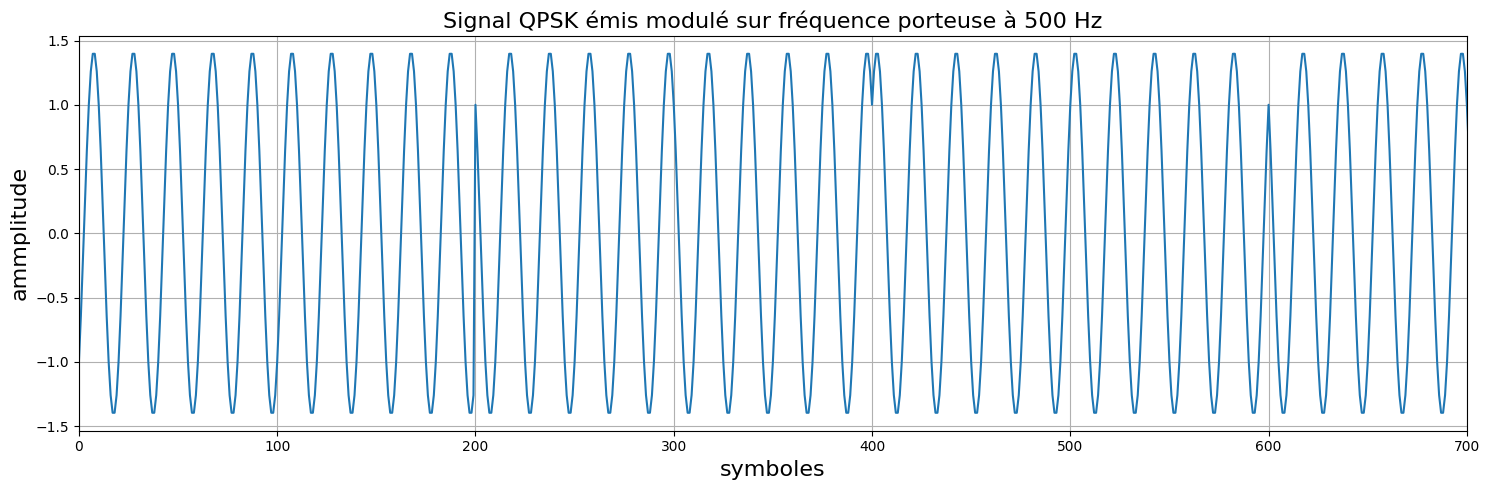

In [81]:
#Enveloppe complexe modulée sur fréquence porteuse
Signal_QPSK_translate = modemQPSK.upconv(Signal_QPSK, fp, te)

ech = np.arange(0, len(Signal_QPSK_translate))

#Affichage du graphique
fig, ax = plt.subplots(figsize = (15, 5))

ax.plot(ech, Signal_QPSK_translate)
ax.set_xlim(0, 1000)
ax.set_title("Signal QPSK émis modulé sur fréquence porteuse à 500 Hz", fontsize = 16)
ax.set_xlabel("symboles", fontsize = 16)
ax.set_ylabel("ammplitude", fontsize = 16)
ax.set_xlim(0,700)
ax.grid()

plt.tight_layout()

### Canal AWGN ###

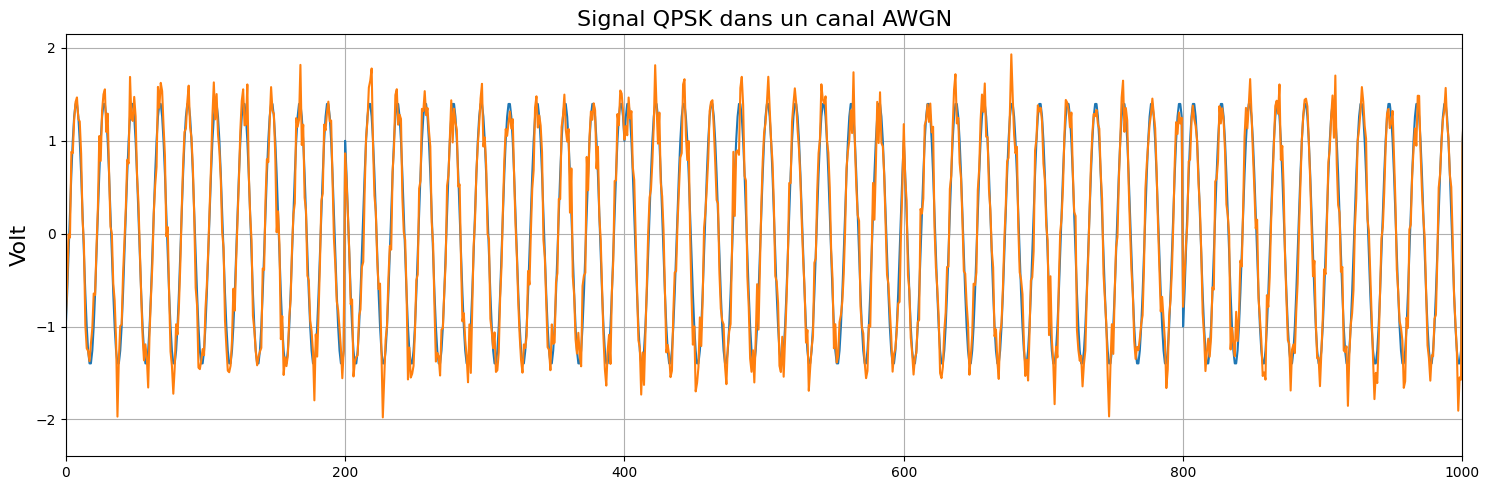

In [82]:
#Ajout d"un bruit blan gaussien avec une moyenne de 0 et une variance de 0.2
Signal_QPSK_bruite = Canal.awgn(Signal_QPSK_translate, 0, 0.2)

#Affichage du graphique
fig, ax = plt.subplots(figsize = (15, 5))

ech = np.arange(len(Signal_QPSK_translate))

ax.plot(ech, Signal_QPSK_translate)
ax.plot(ech, Signal_QPSK_bruite)
ax.set_xlim(0, 1000)
ax.set_ylabel("Volt", fontsize = 16)
ax.set_title("Signal QPSK dans un canal AWGN", fontsize = 16)
ax.grid()

plt.tight_layout()

### Récepteur QPSK ###

In [83]:
Signal_QPSK_down = modemQPSK.downconv(Signal_QPSK_bruite, fp, 1/10e3)

Après translation de fréquence, le spectre du signal sera centré autour de $0 \ et \ -2fp$.<br>
$fp = 500$<br>
Donc le spectre sera centré autour de $0Hz \ et \ -1000Hz$.<br>
Il faudra donc filtrer la composante spectral en $-1000Hz$.

### Affichage du signal entre avant et après translation de fréquence ###

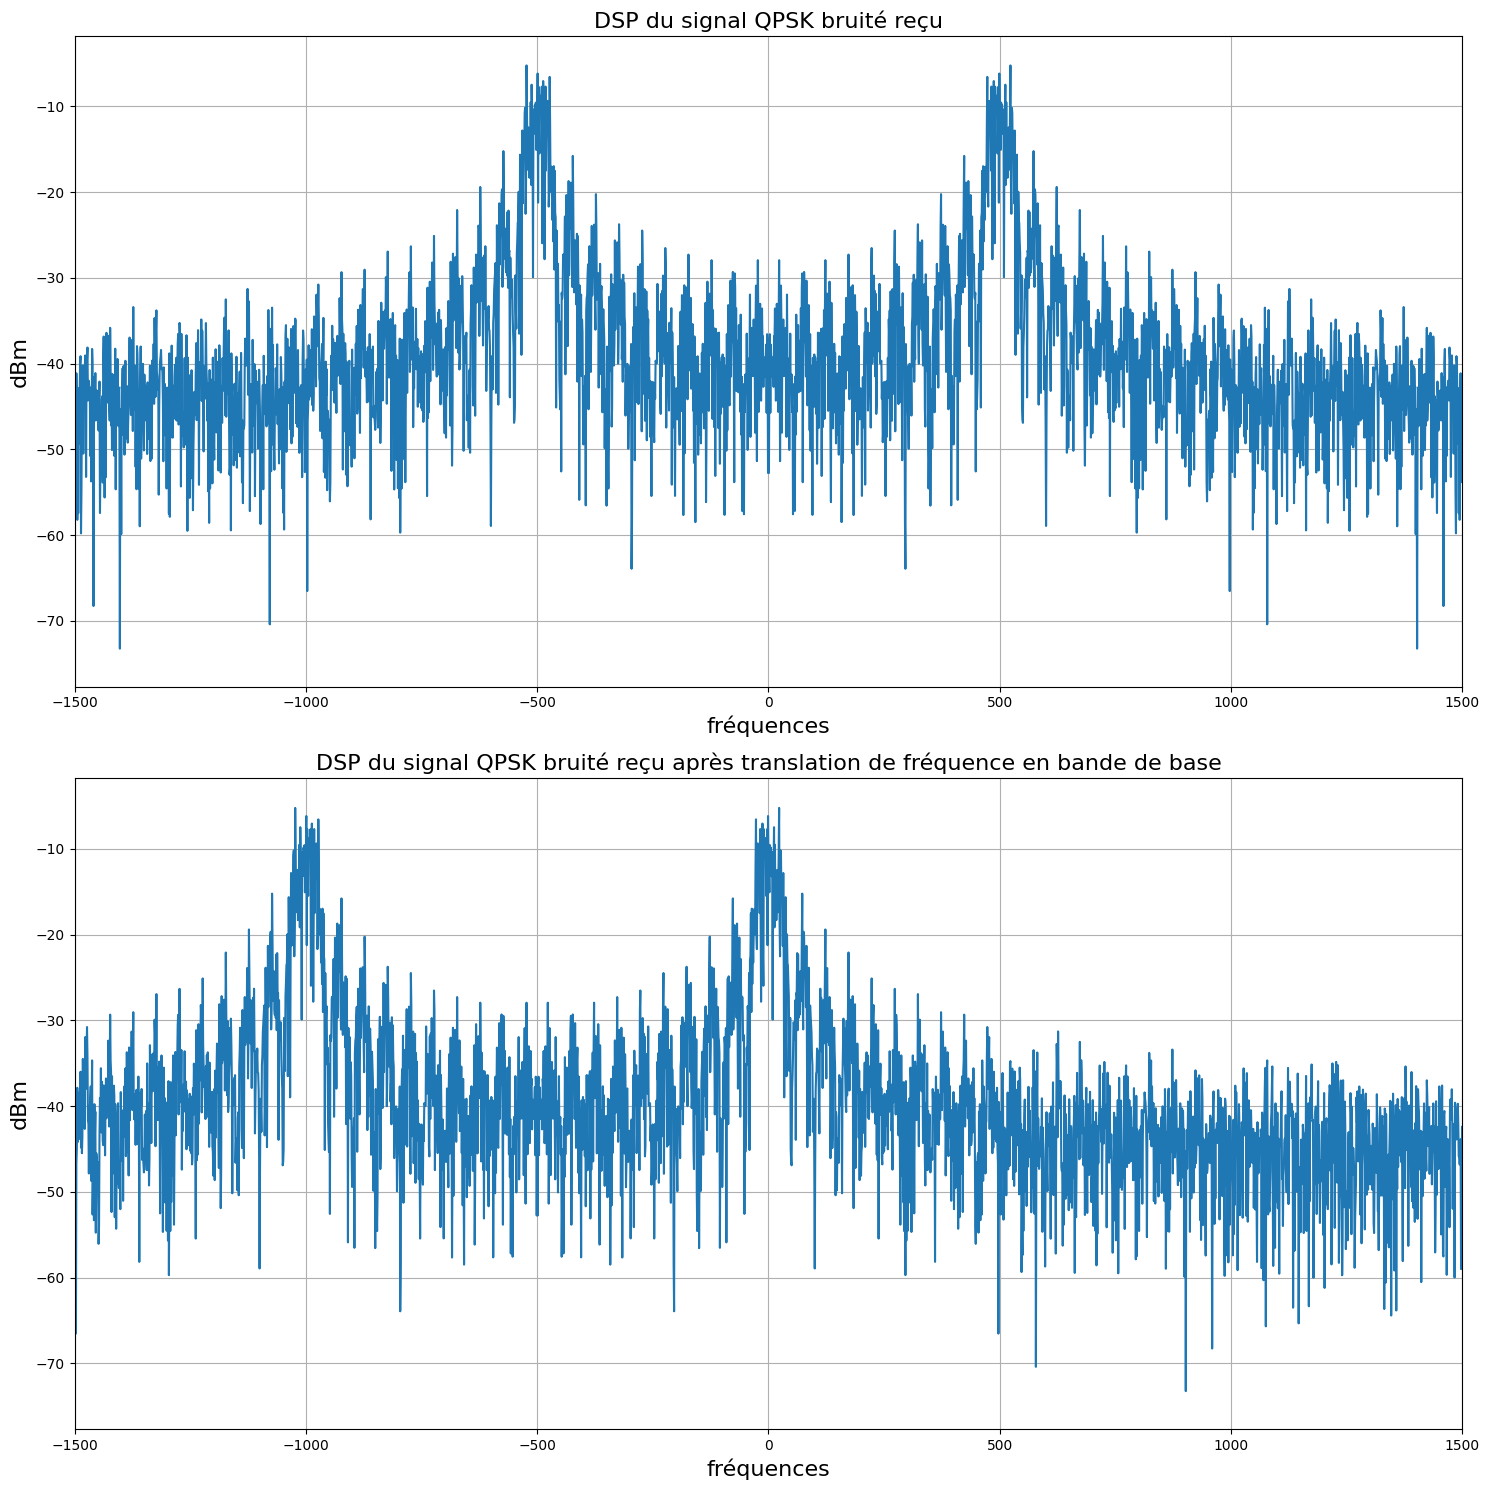

In [84]:
#Génération de la DSP des signaux grâce à une méthode de la classe Mesure
dsp_signal_QPSK_bruite,freq1 = Mesure.dsp(Signal_QPSK_bruite, fe)
dsp_signal_QPSK_down, freq2 = Mesure.dsp(Signal_QPSK_down, fe)

#Affichage des graphiques
fig, ax = plt.subplots(2, 1, figsize = (15, 15))

#DSP du signal bruité
ax[0].plot(freq1, dsp_signal_QPSK_bruite)
ax[0].set_xlim(-1500, 1500)
ax[0].set_xlabel("fréquences", fontsize = 16)
ax[0].set_ylabel("dBm", fontsize = 16)
ax[0].set_title("DSP du signal QPSK bruité reçu", fontsize = 16)
ax[0].grid()

#DSP du signal bruité après downconv
ax[1].plot(freq2, dsp_signal_QPSK_down)
ax[1].set_xlim(-1500, 1500)
ax[1].set_xlabel("fréquences", fontsize = 16)
ax[1].set_ylabel("dBm", fontsize = 16)
ax[1].set_title("DSP du signal QPSK bruité reçu après translation de fréquence en bande de base", fontsize = 16)
ax[1].grid()

plt.tight_layout()

### Filtrage du signal QPSK reçue ###

In [98]:
#Paramètres du filtrage
fe = 10e3
fc = 500
order = 10

print(fc/(fe/2))

#filtrage du signal down
Signal_QPSK_filtre = modemQPSK.filtre_rcv(Signal_QPSK_down, "butter", fc, fe, order)
# print(modemQPSK.fcn)

0.1


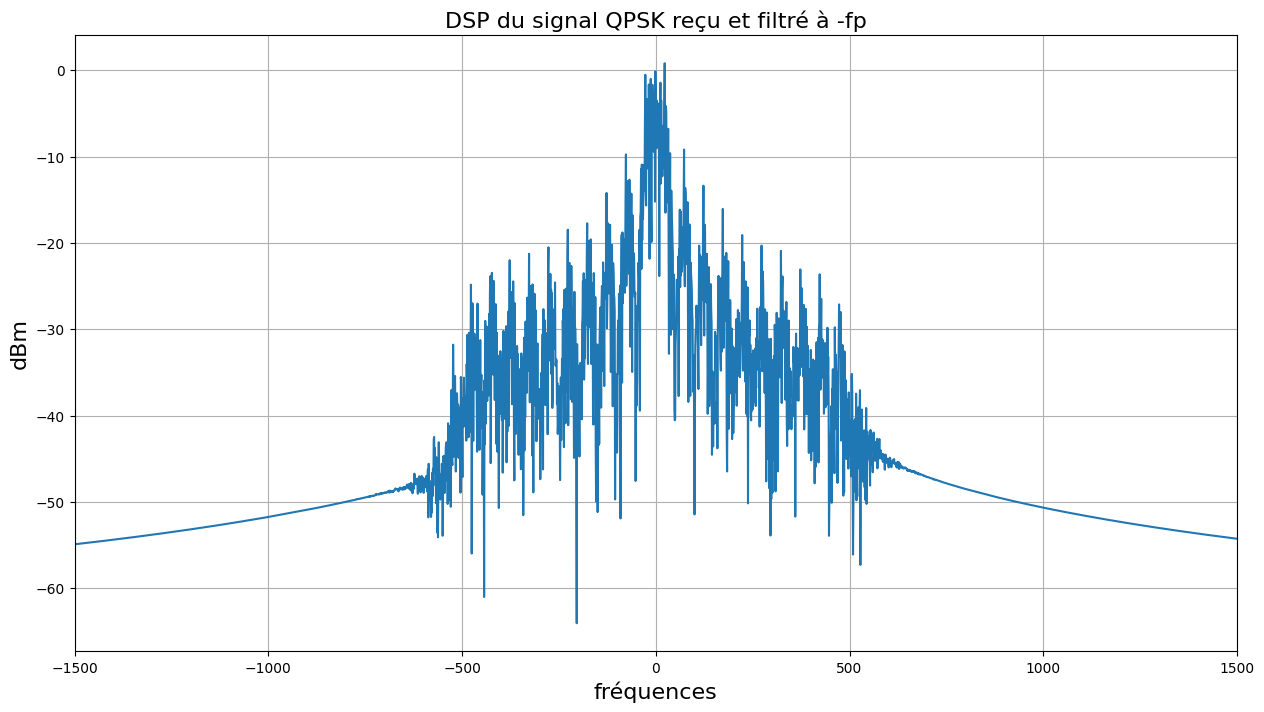

In [99]:
#Génération de la DSP des signaux grâce à une méthode de la classe Mesure
dsp_signal_QPSK_filtre, freq1 = Mesure.dsp(Signal_QPSK_filtre, fe)

#Affichage des graphiques
fig, ax = plt.subplots(figsize = (15, 8))

#DSP du signal bruité
ax.plot(freq1, dsp_signal_QPSK_filtre)
ax.set_xlim(-1500, 1500)
ax.set_xlabel("fréquences", fontsize = 16)
ax.set_ylabel("dBm", fontsize = 16)
ax.set_title("DSP du signal QPSK reçu et filtré à -fp", fontsize = 16)
ax.grid()

### Diagramme de constellation du signal reçu filtré ###

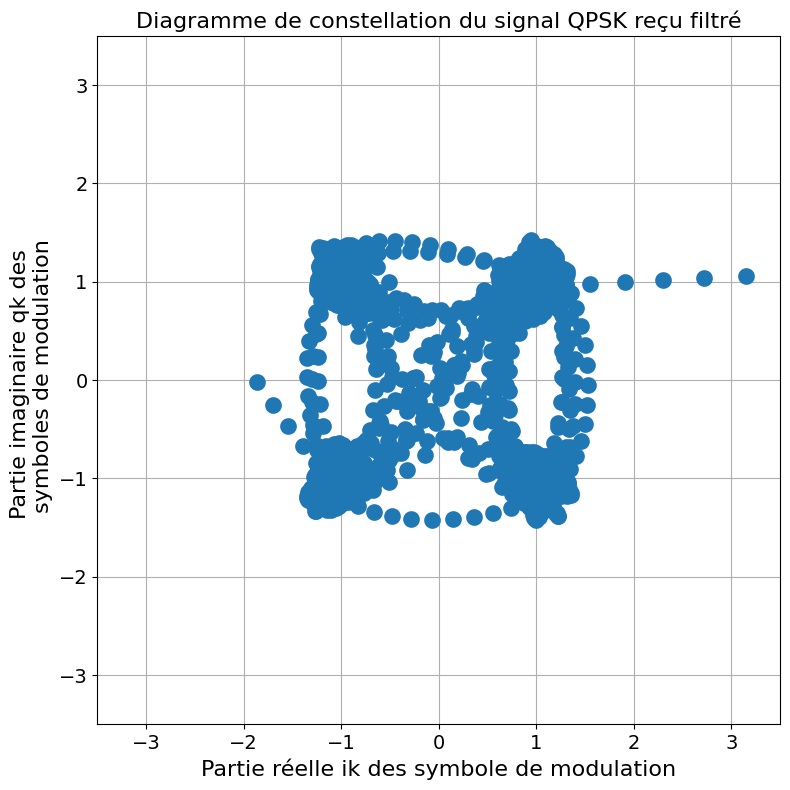

In [87]:
Mesure.constellation(Signal_QPSK_filtre, width=8, title="Diagramme de constellation du signal QPSK reçu filtré")

### Downsampling ###

In [88]:
#Paramètre de downsampling
downsampling = upsampling
offset = int(downsampling/2)

#Downsampling du signal avec la méthode downsample de la classe modem
SymbsQPSK_rcv = modemQPSK.downsample(Signal_QPSK_filtre, downsampling, offset)

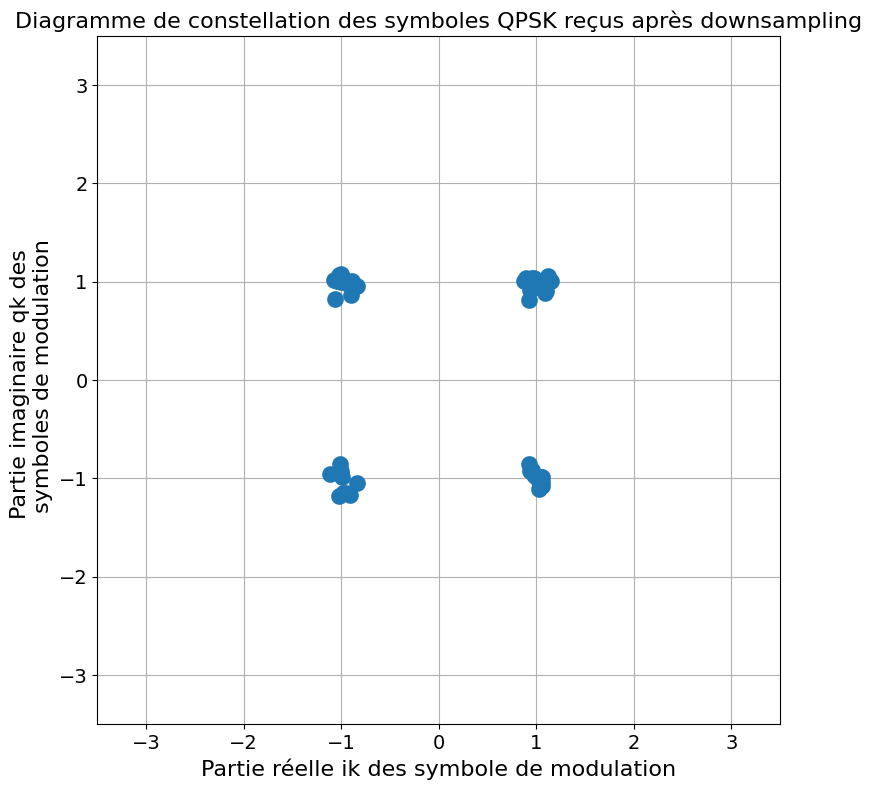

In [89]:
Mesure.constellation(SymbsQPSK_rcv, width=8, title="Diagramme de constellation des symboles QPSK reçus après downsampling")

In [90]:
#Détection des symboles
SymbsQPSK_detect = modemQPSK.detection(SymbsQPSK_rcv)

#Affichage
print(f"Les symboles reçus après detection sont:\n {SymbsQPSK_detect}\n")
print(f"Les symboles émis sont:\n{Symbs_QPSK}\n")

Les symboles reçus après detection sont:
 [-1.-1.j  1.+1.j  1.-1.j  1.+1.j -1.-1.j  1.-1.j  1.-1.j  1.+1.j -1.+1.j
  1.-1.j -1.+1.j  1.-1.j -1.+1.j  1.-1.j  1.-1.j -1.-1.j  1.+1.j -1.+1.j
  1.+1.j  1.-1.j  1.-1.j -1.+1.j -1.-1.j -1.+1.j -1.+1.j  1.+1.j -1.-1.j
 -1.+1.j -1.+1.j -1.+1.j -1.-1.j -1.-1.j  1.+1.j  1.+1.j  1.-1.j  1.+1.j
  1.+1.j -1.-1.j  1.+1.j -1.-1.j  1.+1.j -1.-1.j -1.+1.j -1.+1.j  1.+1.j
  1.-1.j  1.+1.j  1.-1.j  1.+1.j  1.+1.j]

Les symboles émis sont:
[-1.-1.j  1.+1.j  1.-1.j  1.+1.j -1.-1.j  1.-1.j  1.-1.j  1.+1.j -1.+1.j
  1.-1.j -1.+1.j  1.-1.j -1.+1.j  1.-1.j  1.-1.j -1.-1.j  1.+1.j -1.+1.j
  1.+1.j  1.-1.j  1.-1.j -1.+1.j -1.-1.j -1.+1.j -1.+1.j  1.+1.j -1.-1.j
 -1.+1.j -1.+1.j -1.+1.j -1.-1.j -1.-1.j  1.+1.j  1.+1.j  1.-1.j  1.+1.j
  1.+1.j -1.-1.j  1.+1.j -1.-1.j  1.+1.j -1.-1.j -1.+1.j -1.+1.j  1.+1.j
  1.-1.j  1.+1.j  1.-1.j  1.+1.j  1.+1.j]



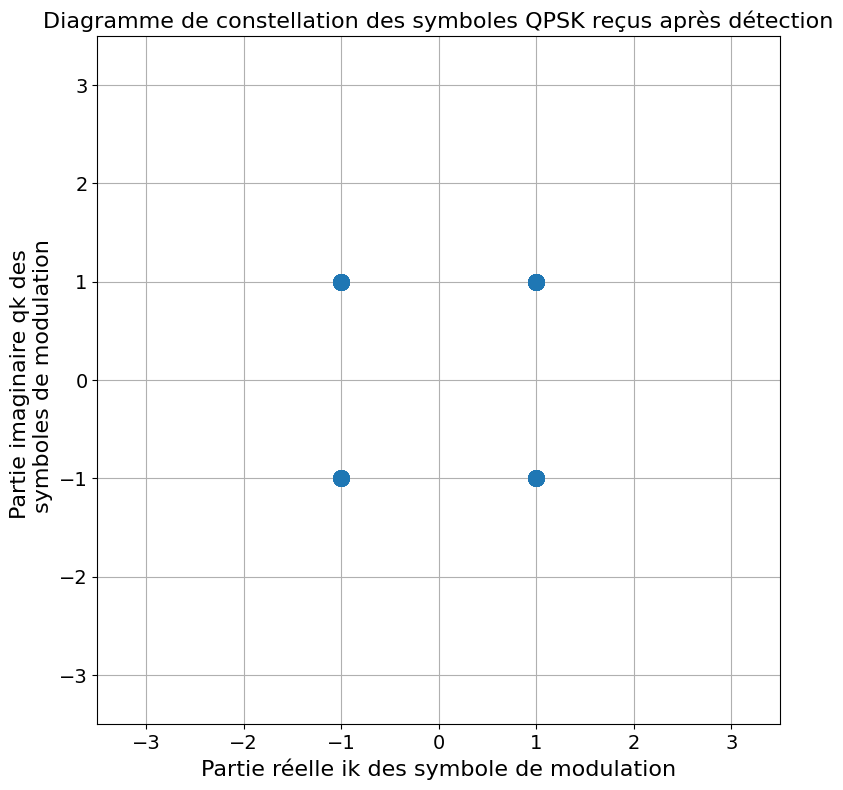

In [91]:
Mesure.constellation(SymbsQPSK_detect, width=8, title="Diagramme de constellation des symboles QPSK reçus après détection")

In [92]:
#Démapping des symboles détéctés
Bits_rcv = modemQPSK.demapping(SymbsQPSK_detect)

#Affichage des bits émis et reçues
print(f"Les bits reçus sont:\n{Bits_rcv}\n")
print(f"Les bits envoyés sont:\n{Bits}\n")

Les bits reçus sont:
[1 0 0 0 1 1 0 0 1 0 1 1 1 1 0 0 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 0 0 0 0 1 0
 0 1 1 1 1 0 1 1 0 0 1 0 1 0 0 1 0 0 1 0 1 0 1 1 0 1 0 0 0 0 0 1 1 0 0 0 0
 1 0 0 0 1 0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 1 1 0 0 0 0]

Les bits envoyés sont:
[1 0 0 0 1 1 0 0 1 0 1 1 1 1 0 0 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 0 0 0 0 1 0
 0 1 1 1 1 0 1 1 0 0 1 0 1 0 0 1 0 0 1 0 1 0 1 1 0 1 0 0 0 0 0 1 1 0 0 0 0
 1 0 0 0 1 0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 1 1 0 0 0 0]



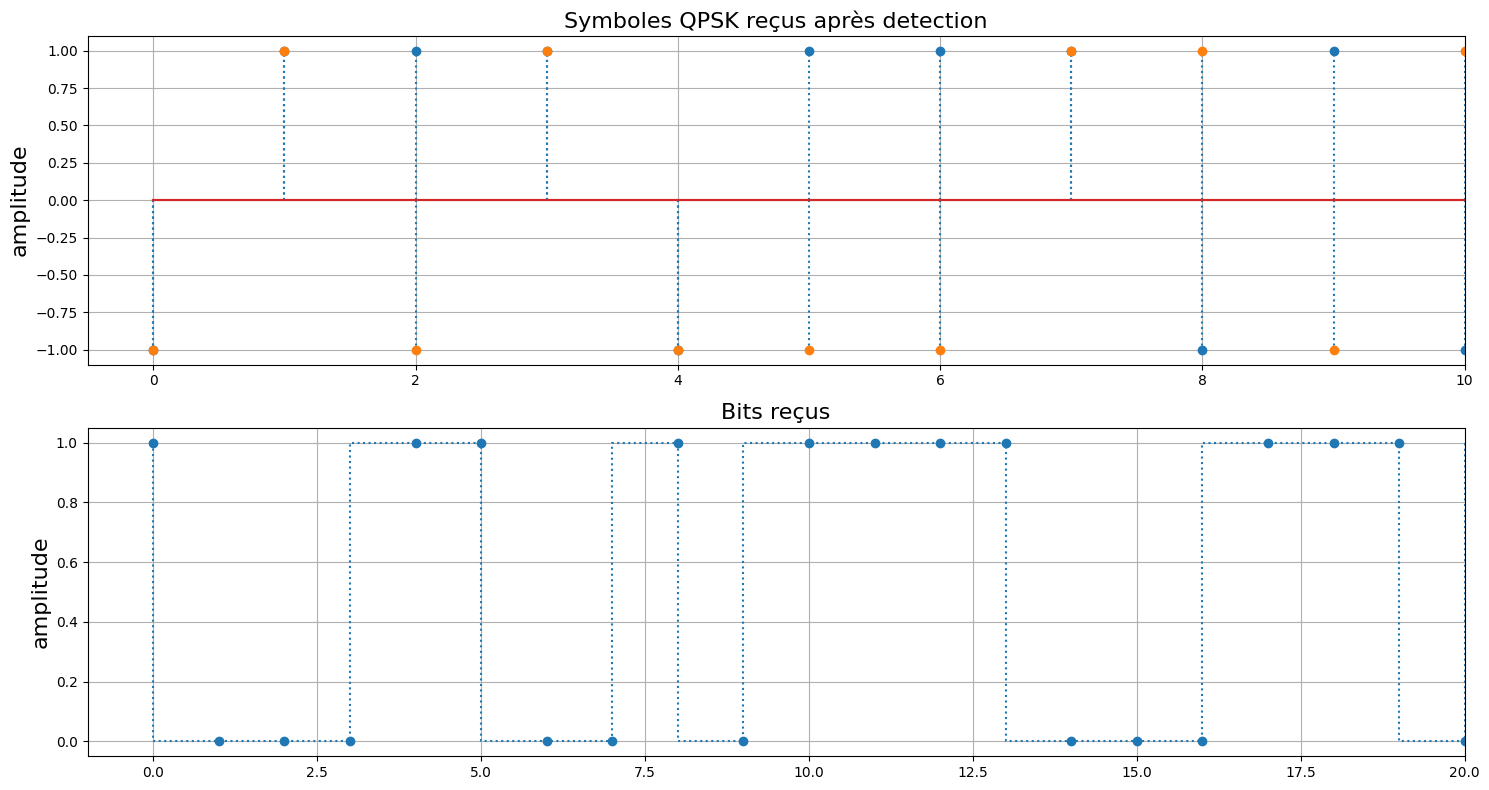

In [93]:
ech1 = np.arange(0, len(SymbsQPSK_detect))
ech2 = np.arange(0, len(Bits_rcv))

fig, ax =  plt.subplots(2, 1, figsize = (15,8))

ax[0].stem(ech1, np.real(SymbsQPSK_detect), ":o")
ax[0].stem(ech1, np.imag(SymbsQPSK_detect), ":o")
ax[0].set_xlim(-0.5,10)
ax[0].set_ylabel("amplitude", fontsize = 16)
ax[0].set_title("Symboles QPSK reçus après detection", fontsize = 16)
ax[0].grid()

ax[1].step(ech2, Bits_rcv, ":o")
ax[1].set_xlim(-1, 20)
ax[1].set_ylabel("amplitude", fontsize = 16)
ax[1].set_title("Bits reçus", fontsize = 16)
ax[1].grid()

plt.tight_layout()

### Comparaison entre l"émission et la réception des données ###

In [94]:
taux_erreur = Mesure.comparaison(SymbsQPSK_detect, Symbs_QPSK)
print(f"Le taux d"erreur est de: {taux_erreur}%" )

SyntaxError: unterminated string literal (detected at line 2) (2557762476.py, line 2)

## Envoie et réception d"un paqet ICMP avec modulation QPSK ##

In [161]:
# ####################################################################
# ########### Caractéristiques de la transmission ####################
# ####################################################################

# #Emetteur
# umpsampling = 200

# #Upconverter
# fe = 10e3
# te = 1/fe
# fp = 500

# #Canal
# moyenne = 0
# variance = 0.2

# #downconverter
# fc = 500
# ordre = 8

# #Récepteur
# downsampling = umpsampling
# offset = int(downsampling/2)

# ####################################################################
# ############                  Emmeteur                 #############
# ####################################################################
# #Sources
# Trame_ICMP = Source.icmp("8.8.8.8", "192.168.10.4")

# #Création et initialisation des paramètres du modem (création de l"objet)
# modemQPSK = Modem("PSK", 4, Trame_ICMP)

# #Mapping
# Symbs_QPSK = modemQPSK.mapping(np.sqrt(2))

# #Filtre de mise en forme
# Signal_QPSK = modemQPSK.filtre_MF(Symbs_QPSK, umpsampling)

# ####################################################################
# ############                  Upconverter              #############
# ####################################################################
# Signal_QPSK_translate = modemQPSK.upconv(Signal_QPSK, fp, te)

# ####################################################################
# ############                 Canal AWGN               ##############
# ####################################################################
# Signal_QPSK_bruite = Canal.awgn(Signal_QPSK_translate, moyenne, variance)

# ####################################################################
# ############                 Downconverter             #############
# ####################################################################
# Signal_QPSK_down = modemQPSK.downconv(Signal_QPSK_bruite, fp, te)

# #filtrage du signal down
# Signal_QPSK_filtre = modemQPSK.filtre_rcv(Signal_QPSK_down, "butter", fc, fe, ordre)

# ####################################################################
# ############                 Récepteur               ###############
# ####################################################################
# #Downsampling
# SymbsQPSK_rcv = modemQPSK.downsample(Signal_QPSK_filtre, downsampling, offset)

# #Détection
# SymbsQPSK_detect = modemQPSK.detection(SymbsQPSK_rcv)

# #Démapping
# Trame_ICMP_rcv = modemQPSK.demapping(SymbsQPSK_detect)

# Trame_decode = Source.decodage(Trame_ICMP_rcv)

# ####################################################################
# ############                 Affichage               ###############
# ####################################################################
# print(f"Les bits émis sont:\n{Trame_ICMP}\n")
# print (f"Les bits reçues sont:\n{Trame_ICMP_rcv}\n")
# print(f"La trame ICMP décodé est:\n")
# Trame_decode.show()

# taux_erreur = Mesure.comparaison(Trame_ICMP_rcv, Trame_ICMP)
# print(f"Le taux d"erreur est de: {taux_erreur}%" )
